# Training the U-Net Model for Gap Filling (Streaming Architecture)

This notebook trains a Convolutional Neural Network (CNN) to reconstruct missing Chlorophyll-a (Chl-a) data caused by cloud cover. 

Unlike standard in-memory training, this notebook utilizes a high-performance **streaming architecture** via `xbatcher`. It reads raw, chunked `IO.zarr` data directly from a local network drive, dynamically engineers features (like fake clouds and time variables) on the fly, and feeds them directly to the GPU. This prevents memory (RAM) crashes when working with massive oceanographic datasets.

**Environment Setup:** * Runs in JupyterHub with GPU (`pangeo/ml-notebook:2025.08.14` or newer).
* Ensure `mindthegap` and `zarr` are installed in your environment.

In [6]:
import os
import calendar
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
import tensorflow as tf
from tensorflow.keras import Input, layers
from tensorflow.keras.callbacks import EarlyStopping
from xbatcher import BatchGenerator
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Custom package
%pip install -q git+https://github.com/oceanhackweek/ohw25_proj_gap.git@main
import mindthegap as mtg

# Suppress TF warnings and enable memory growth
os.environ.pop("TF_CUDNN_DETERMINISTIC", None)
os.environ.pop("TF_CUDNN_USE_AUTOTUNE", None)
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_CPP_VMODULE"] = "conv_algorithm_picker=0,cuda_timer=0"

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth successfully enabled for GPU.")
    except RuntimeError as e:
        print(e)

Note: you may need to restart the kernel to use updated packages.
Memory growth successfully enabled for GPU.


## 1. Data Loading & Global Statistics
Load the raw Zarr file from the local shared drive and establish the normalization statistics.

In [7]:
# 1. Load the RAW data from the local shared drive
zarr_raw = xr.open_zarr(os.path.expanduser("~/shared/mind_the_chl_gap/IO.zarr"))

# 2. Crop to your specific Arab Sea bounding box
lat_min, lat_max = 5, 31
lon_min, lon_max = 42, 80
zarr_raw = zarr_raw.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))

# 3. Apply the multiple of 8 crop for the U-Net architecture
ds_cropped = mtg.crop_to_multiple(zarr_raw, multiple=8)

# 4. Cast floats to float32 to save memory
for v in ds_cropped.data_vars:
    if np.issubdtype(ds_cropped[v].dtype, np.floating):
        ds_cropped[v] = ds_cropped[v].astype("float32")

# 5. Load Target Statistics from local prep file
datadir = "/home/jovyan/shared-public/mindthegap/data"
zarr_label = "2015_3_ArabSea"
mean_std = np.load(f'{datadir}/{zarr_label}.npy', allow_pickle=True).item()
y_mean, y_std = mean_std['CHL'][0], mean_std['CHL'][1]

# 6. Define Global Feature Statistics for on-the-fly normalization
feature_stats = {
    'sst': [28.0, 2.0],  
    'so':  [36.0, 1.0],  
    'ug_curr': [0.0, 0.5],
    'v_curr': [0.0, 0.5]
}

print("Raw data loaded and global statistics initialized.")

Raw data loaded and global statistics initialized.


## 2. Build model: U-Net

#### What is U-Net?
U-Net is a Convolutional Neural Network (CNN) architecture. CNNs are deep learning models particularly effective for visual data and high-dimensional spatial analysis. They are powerful in capturing spatial hierarchies and patterns. 

U-Net follows an autoencoder architecture. The **encoder** half down-samples input images progressively and extracts features, while the **decoder** half constructs predictions based on these features. It is highly effective and accurate even with relatively limited data.

#### Model Architecture
This model uses three encoder layers (filter sizes 64, 128, 256) and three decoder layers (filter sizes 128, 64, 1). 
* Each encoder block consists of two `Conv2D` layers, one `MaxPool2D` layer, and one `BatchNormalization` layer. 
* Each decoder block consists of one `Conv2DTranspose` layer, one `Concatenate` layer, two `Conv2D` layers, and one `BatchNormalization` layer. 
* The output of the final decoder layer is the gap-filled prediction of Chl-a.

**Layer Definitions:**
* `Conv2D`: Applies 2D convolution operations to the input for feature detection (lines, edges, patterns) in the encoder, and for making predictions in the decoder. 
  * `filters`: Number of output channels and features detected. 
  * `kernel_size`: Size of the filters (all filters here are 3x3). 
  * `padding`: Adds extra pixels to inputs. `same` ensures output dimensions match the input. 
  * `activation`: Introduces non-linearity. Most layers use `ReLU` (outputs input directly if positive, 0 if negative). The final layer uses `linear` due to potential negative values in log(Chl-a) predictions.
* `MaxPooling2D`: Downsamples the input by taking the maximum in a given window (2x2). It reduces computational complexity while retaining significant features.
* `BatchNormalization`: Normalizes the input, reducing overfitting and improving generalizability.
* `Conv2DTranspose`: Performs a "reverse" convolution to upsample the input, doubling the spatial dimensions.
* `Concatenate`: Merges the upsampled feature maps with the high-resolution feature maps passed over from the corresponding encoder stage.

#### Model Compilation
We use `.compile()` to configure the model for training.
* `optimizer`: Adjusts model parameters during training to minimize loss. We use `Adam` for faster convergence via adaptive learning rates.
* `loss`: The objective function the model minimizes. We use Mean Squared Error (MSE) for its effectiveness in regression tasks.
* `metrics`: Evaluators monitored during training. We track Mean Absolute Error (MAE) for additional performance context.

In [15]:
def UNet(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs
    filters = [64, 128, 256]
    ec_images = []

    for filter in filters:
        ec_images.append(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.MaxPooling2D()(x)
        x = layers.BatchNormalization()(x)

    for filter, ec_image in zip(filters[:-1][::-1], ec_images[::-1][:-1]):
        x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)
        x = layers.concatenate([x, ec_image])
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(filter, 3, 2, padding='same')(x)
    x = layers.concatenate([x, ec_images[0]])
    x = layers.Conv2D(filters=filter, kernel_size=(3, 3), padding='same', activation='relu')(x)
    
    outputs = layers.Conv2D(filters=1, kernel_size=(3,3), padding='same', activation='linear')(x)

    unet_model = tf.keras.Model(inputs, outputs, name='U-net')
    unet_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return unet_model

## 3. Streaming Pipeline & Dynamic Feature Engineering

Because we cannot fit the entire dataset in memory, we use `xbatcher` to stream 100-day blocks of data. We then use a Python Generator (`make_tf_gen`) to engineer the features our model needs milliseconds before passing them to the GPU.

**Dynamic Features Engineered:**
* **Fake Clouds:** To teach the model how to fill gaps, we simulate missing data by taking the real cloud mask from 10 days in the future and applying it to today's gap-free truth.
* **Masked CHL:** The input Chlorophyll-a data with holes punched into it where the fake clouds sit.
* **Time Variables:** Sine and Cosine waves representing the day of the year, helping the model learn seasonal oceanographic patterns.

The generator standardizes these features, stacks them into a 6-channel tensor, and yields them to the TensorFlow dataset iteratively.

In [17]:
# 1. Define Model Dimensions
X_vars = ['sst', 'so', 'sin_time', 'cos_time', 'masked_CHL', 'fake_cloud_flag'] 
num_features = len(X_vars) 
lat_size = ds_cropped.sizes['lat']
lon_size = ds_cropped.sizes['lon']
input_shape = (lat_size, lon_size, num_features)

model = UNet(input_shape)
model.summary()

output_signature = (
    tf.TensorSpec(shape=(lat_size, lon_size, num_features), dtype=tf.float32),
    tf.TensorSpec(shape=(lat_size, lon_size, 1), dtype=tf.float32)
)

# 2. Slice the dataset using ONLY the raw variables needed from the drive
raw_vars_to_keep = ['sst', 'so', 'CHL_cmes-cloud', 'CHL_cmes-gapfree', 'CHL_cmes-level3']

train_year, train_range, val_range, test_range = 2015, 3, 1, 1

ds_train = ds_cropped[raw_vars_to_keep].sel(time=slice(f'{train_year}-01-01', f'{train_year+train_range}-01-01'))
ds_val = ds_cropped[raw_vars_to_keep].sel(time=slice(f'{train_year+train_range}-01-01', f'{train_year+train_range+val_range}-01-01'))

# 3. Setup batchers for 100-day chunk alignment
input_dims = {"time": 100, "lat": lat_size, "lon": lon_size}
input_overlap = {"time": 0, "lat": 0, "lon": 0}

train_batcher = BatchGenerator(ds_train, input_dims=input_dims, input_overlap=input_overlap)
val_batcher = BatchGenerator(ds_val, input_dims=input_dims, input_overlap=input_overlap)

# 4. Dynamic Feature Generator
def make_tf_gen(batcher, x_vars):
    def gen():
        for batch in batcher:
            time_len = batch.sizes["time"]
            for t in range(time_len):
                # Fake Clouds (Shifted by 10 days)
                fake_t = (t + 10) % time_len 
                fake_cloud_flag = batch['CHL_cmes-cloud'].isel(time=fake_t).values
                fake_cloud_flag = np.where(np.isnan(fake_cloud_flag), 0.0, fake_cloud_flag)

                # True CHL & Masked CHL
                raw_true_chl = batch['CHL_cmes-gapfree'].isel(time=t).values
                with np.errstate(divide='ignore', invalid='ignore'):
                    log_true_chl = np.log(raw_true_chl)
                    
                true_chl_std = (log_true_chl - y_mean) / y_std
                true_chl_std = np.where(np.isnan(true_chl_std), 0.0, true_chl_std)
                true_chl_std = np.where(np.isinf(true_chl_std), 0.0, true_chl_std)
                masked_chl = np.where(fake_cloud_flag == 1, 0.0, true_chl_std)

                # Time Variables
                day_of_year = batch['time'].isel(time=t).dt.dayofyear.item()
                sin_grid = np.full(raw_true_chl.shape, np.sin(2 * np.pi * day_of_year / 365), dtype=np.float32)
                cos_grid = np.full(raw_true_chl.shape, np.cos(2 * np.pi * day_of_year / 365), dtype=np.float32)

                # Assemble Input Tensor
                x_slice = []
                for var in x_vars:
                    if var == 'masked_CHL':
                        x_slice.append(masked_chl)
                    elif var == 'fake_cloud_flag':
                        x_slice.append(fake_cloud_flag)
                    elif var == 'sin_time':
                        x_slice.append(sin_grid)
                    elif var == 'cos_time':
                        x_slice.append(cos_grid)
                    else:
                        raw_val = np.where(np.isnan(batch[var].isel(time=t).values), 0.0, batch[var].isel(time=t).values)
                        final_val = (raw_val - feature_stats[var][0]) / feature_stats[var][1] if var in feature_stats else raw_val
                        x_slice.append(final_val)

                x = np.stack(x_slice, axis=-1).astype(np.float32)
                y = true_chl_std.astype(np.float32)[..., np.newaxis]
                yield x, y
    return gen

# 5. Build TF Datasets
train_dataset = tf.data.Dataset.from_generator(
    make_tf_gen(train_batcher, X_vars), output_signature=output_signature
).shuffle(100).batch(1).repeat().prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    make_tf_gen(val_batcher, X_vars), output_signature=output_signature
).batch(1).repeat().prefetch(tf.data.AUTOTUNE)

# 6. Fit the Model
train_steps = ds_train.sizes['time']
val_steps = ds_val.sizes['time']
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_dataset, 
    epochs=50, 
    steps_per_epoch=train_steps, 
    validation_data=val_dataset, 
    validation_steps=val_steps, 
    callbacks=[early_stop]
)

Model: "U-net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 104, 152,  │          0 │ -                 │
│ (InputLayer)        │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 104, 152,  │      3,520 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 104, 152,  │     36,928 │ conv2d_24[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 52, 76,    │          0 │ conv2d_25[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 76,    │        256 │ max_pooling2d_6[… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 52, 76,    │     73,856 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 52, 76,    │    147,584 │ conv2d_26[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 26, 38,    │          0 │ conv2d_27[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 38,    │        512 │ max_pooling2d_7[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 26, 38,    │    295,168 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 26, 38,    │    590,080 │ conv2d_28[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 13, 19,    │          0 │ conv2d_29[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 19,    │      1,024 │ max_pooling2d_8[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 26, 38,    │    295,040 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 26, 38,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 26, 38,    │    295,040 │ concatenate_6[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 26, 38,    │    147,584 │ conv2d_30[0][0] 

 Total params: 2,149,761 (8.20 MB)

 Trainable params: 2,148,481 (8.20 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - loss: 0.3613 - mae: 0.3475 - val_loss: 0.2618 - val_mae: 0.3071
Epoch 2/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.1937 - mae: 0.2614 - val_loss: 0.5869 - val_mae: 0.4875
Epoch 3/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.1271 - mae: 0.2054 - val_loss: 0.2791 - val_mae: 0.2864
Epoch 4/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0909 - mae: 0.1667 - val_loss: 0.1799 - val_mae: 0.2349
Epoch 5/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0809 - mae: 0.1530 - val_loss: 0.1829 - val_mae: 0.2284
Epoch 6/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - loss: 0.0710 - mae: 0.1395 - val_loss: 0.1559 - val_mae: 0.2087
Epoch 7/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0682 - mae: 0.1344 - val_loss: 0.1565 - val_mae: 0.2090
Epoch 8/50
1097/1097 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - loss: 0.0627 - mae: 0.1268 - val_loss: 0.1504 - val_mae: 0.1896
Epoch 9/50
1097/1097 ━━━

## 4. Model Evaluation & Saving

Testing is also performed via the streaming generator to prevent memory overflow. We use `.evaluate()` on a dedicated holdout test dataset (e.g., data from a subsequent year unseen by the model during training). 

Because the generator runs continuously, we explicitly pass `test_steps` to the evaluation function so Keras knows exactly when to stop requesting new batches.

In [18]:
def evaluate_test_set():
    ds_test = ds_cropped[raw_vars_to_keep].sel(time=slice(f'{train_year+train_range+val_range}-01-01', f'{train_year+train_range+val_range+test_range}-01-01'))
    test_batcher = BatchGenerator(ds_test, input_dims=input_dims, input_overlap=input_overlap)
    
    test_dataset = tf.data.Dataset.from_generator(
        make_tf_gen(test_batcher, X_vars), output_signature=output_signature
    ).batch(1)
    
    test_steps = ds_test.sizes['time']
    test_mse, test_mae = model.evaluate(test_dataset, steps=test_steps)
    
    print(f"Test MSE: {test_mse}")
    print(f"Test MAE: {test_mae}")
    return test_mse, test_mae

test_mse, test_mae = evaluate_test_set()

# Save Model
model_name = 'UNet_Streaming_mse'
folder_path= f'models/{zarr_label}'
os.makedirs(folder_path, exist_ok=True)
model.save(f'{folder_path}/{model_name}.keras')

366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1630 - mae: 0.2203
Test MSE: 0.16302691400051117
Test MAE: 0.2203313410282135


2026-06-30 04:26:58.137018: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/srv/conda/envs/notebook/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


## 5. Visualizations

Visualizing the model's predictions helps us qualitatively and quantitatively assess its performance. 

* **Prediction vs. Observation:** Compares the U-Net prediction against real Level-3 observations containing natural gaps.
* **Gapfill Comparison:** Compares the U-Net prediction against the highly processed Copernicus Gapfree (Level-4) product. 
* **Annual Mean Absolute Difference (MAD):** Evaluates the average daily error between the model and the gap-free truth over an entire year, plotted alongside the daily cloud percentage to visualize performance under varying levels of missing data.

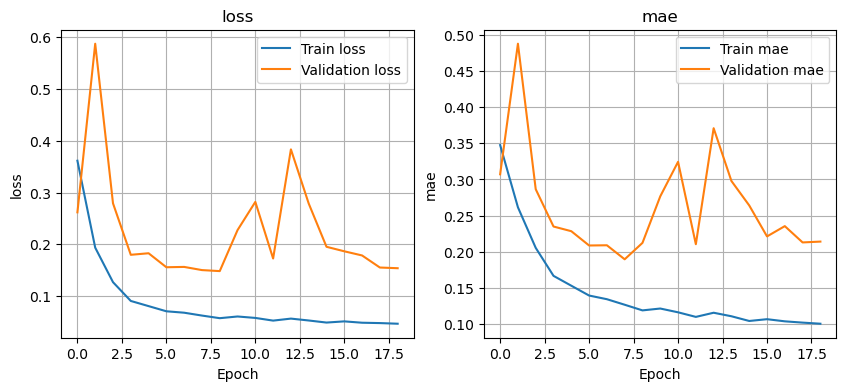

In [19]:
def plot_losses(history):
    history_keys = list(history.history.keys())
    plot_num = len(history_keys) // 2
    plt.figure(figsize=(5 * plot_num, 4))
    for i in range(plot_num):
        train_key = history_keys[i]
        val_key = history_keys[i + plot_num]
        plt.subplot(1, plot_num, i + 1)
        plt.plot(history.history[train_key], label=f'Train {train_key}')
        plt.plot(history.history[val_key], label=f'Validation {val_key[4:]}')
        plt.title(train_key)
        plt.xlabel('Epoch')
        plt.ylabel(train_key)
        plt.legend(loc='upper right')
        plt.grid(True)
    plt.show()

plot_losses(history)

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


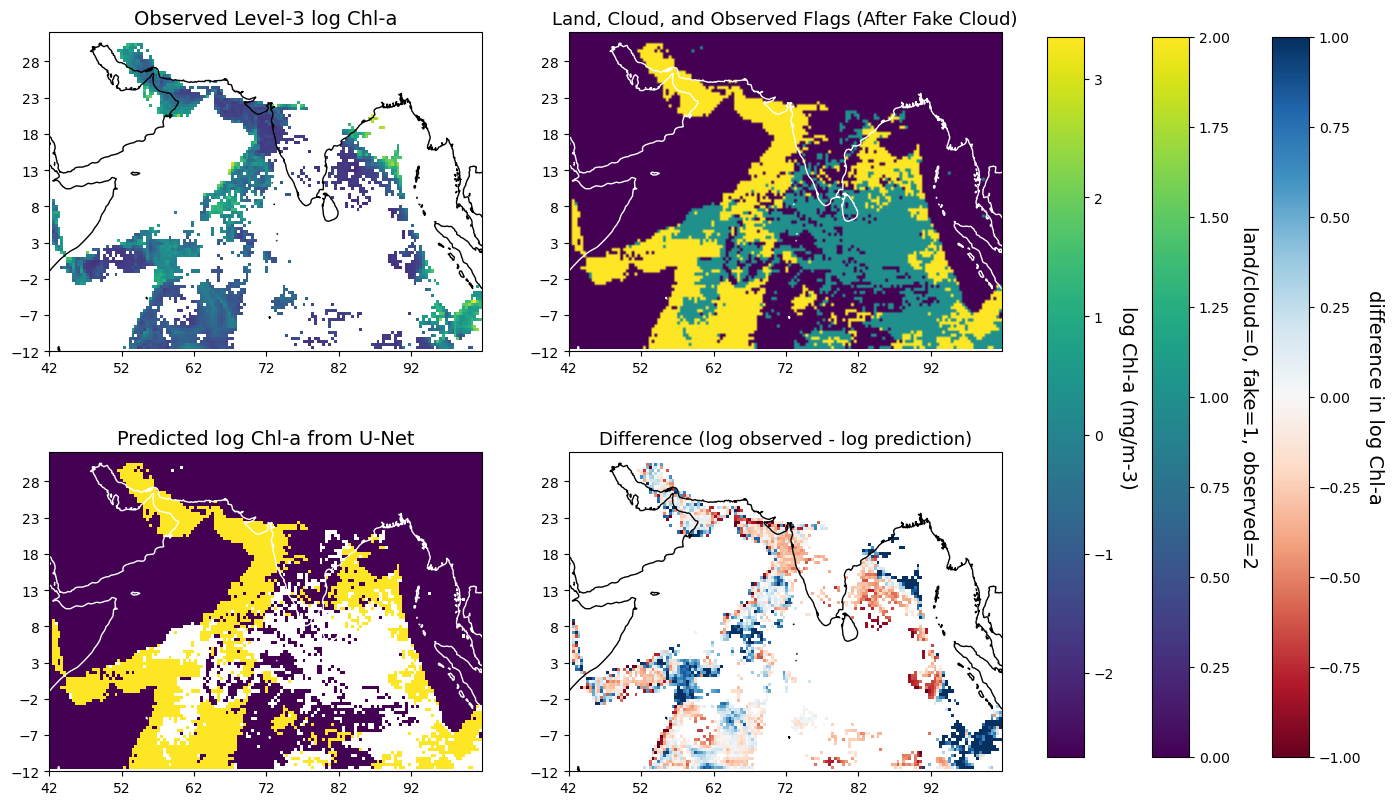

In [12]:
def plot_prediction_observed(zarr_stdized, model, date_to_predict):
    target_date = pd.to_datetime(date_to_predict)
    fake_cloud_date = target_date + pd.Timedelta(days=10)
    zarr_date = zarr_stdized.sel(time=target_date)
    
    # 1. Dynamically Build Features
    try:
        fake_cloud_flag = zarr_stdized['CHL_cmes-cloud'].sel(time=fake_cloud_date).values
    except KeyError:
        fake_cloud_flag = zarr_date['CHL_cmes-cloud'].values 
    fake_cloud_flag = np.where(np.isnan(fake_cloud_flag), 0.0, fake_cloud_flag)
    
    raw_true_chl = zarr_date['CHL_cmes-gapfree'].values
    with np.errstate(divide='ignore', invalid='ignore'):
        log_true_chl = np.log(raw_true_chl)
    
    true_chl_std = (log_true_chl - y_mean) / y_std
    true_chl_std = np.where(np.isnan(true_chl_std), 0.0, true_chl_std)
    true_chl_std = np.where(np.isinf(true_chl_std), 0.0, true_chl_std)
    
    masked_chl = np.where(fake_cloud_flag == 1, 0.0, true_chl_std)
    
    day_of_year = target_date.dayofyear
    sin_grid = np.full(raw_true_chl.shape, np.sin(2 * np.pi * day_of_year / 365), dtype=np.float32)
    cos_grid = np.full(raw_true_chl.shape, np.cos(2 * np.pi * day_of_year / 365), dtype=np.float32)

    # Assemble Input
    x_slice = []
    for var in X_vars:
        if var == 'masked_CHL': x_slice.append(masked_chl)
        elif var == 'fake_cloud_flag': x_slice.append(fake_cloud_flag)
        elif var == 'sin_time': x_slice.append(sin_grid)
        elif var == 'cos_time': x_slice.append(cos_grid)
        else:
            raw_val = np.where(np.isnan(zarr_date[var].values), 0.0, zarr_date[var].values)
            final_val = (raw_val - feature_stats[var][0]) / feature_stats[var][1] if var in feature_stats else raw_val
            x_slice.append(final_val)
            
    X = np.stack(x_slice, axis=-1).astype(np.float32)
    
    # Predict
    predicted_CHL_std = model.predict(X[np.newaxis, ...], verbose=0)[0, :, :, 0]
    predicted_CHL = (predicted_CHL_std * y_std) + y_mean
    
    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(zarr_date['CHL_cmes-level3'].values)
        
    predicted_CHL = np.where(np.isnan(true_CHL), np.nan, predicted_CHL)
    diff = true_CHL - predicted_CHL

    flag = np.zeros(true_CHL.shape)
    if 'CHL_cmes-land' in zarr_stdized:
        flag = np.where(zarr_stdized['CHL_cmes-land'].values == 1, 0, flag)
    flag = np.where(zarr_date['CHL_cmes-cloud'].values == 1, 0, flag)
    flag = np.where(fake_cloud_flag == 1, 1, flag)
    flag = np.where(~np.isnan(true_CHL), 2, flag)

    vmax, vmin = np.nanmax((true_CHL, predicted_CHL)), np.nanmin((true_CHL, predicted_CHL))
    extent = [42, 101.75, -11.75, 32]

    # Plotting
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    
    im0 = axes[0, 0].imshow(true_CHL, vmin=vmin, vmax=vmax, extent=extent, origin='upper', transform=ccrs.PlateCarree(), interpolation='nearest')
    axes[0, 0].add_feature(cfeature.COASTLINE)
    axes[0, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 0].set_title('Observed Level-3 log Chl-a', size=14)

    im1 = axes[0, 1].imshow(flag, extent=extent, origin='upper', transform=ccrs.PlateCarree())
    axes[0, 1].add_feature(cfeature.COASTLINE, color='white')
    axes[0, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 1].set_title('Land, Cloud, and Observed Flags (After Fake Cloud)', size=13)

    im2 = axes[1, 0].imshow(predicted_CHL, vmin=vmin, vmax=vmax, extent=extent, origin='upper', transform=ccrs.PlateCarree(), interpolation='nearest')
    axes[1, 0].add_feature(cfeature.COASTLINE, color='white')
    axes[1, 0].imshow(np.where(flag == 1, np.nan, flag), vmax=2, vmin=0, extent=extent, origin='upper', interpolation='nearest', alpha=1)
    axes[1, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 0].set_title('Predicted log Chl-a from U-Net', size=14)

    im3 = axes[1, 1].imshow(diff, vmin=-1, vmax=1, extent=extent, origin='upper', transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu, interpolation='nearest')
    axes[1, 1].add_feature(cfeature.COASTLINE)
    axes[1, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 1].set_title('Difference (log observed - log prediction)', size=13)

    fig.subplots_adjust(right=0.76)
    cbar1 = fig.colorbar(im0, cax=fig.add_axes([0.79, 0.14, 0.025, 0.72]))
    cbar1.ax.set_ylabel('log Chl-a (mg/m-3)', rotation=270, size=14, labelpad=16)
    cbar2 = fig.colorbar(im1, cax=fig.add_axes([0.86, 0.14, 0.025, 0.72]))
    cbar2.ax.set_ylabel('land/cloud=0, fake=1, observed=2', rotation=270, size=14, labelpad=20)
    cbar3 = fig.colorbar(im3, cax=fig.add_axes([0.94, 0.14, 0.025, 0.72]))
    cbar3.ax.set_ylabel('difference in log Chl-a', rotation=270, size=14, labelpad=16)
    
    plt.show()

# Run Prediction Map
plot_prediction_observed(ds_cropped, model, '2020-09-08')

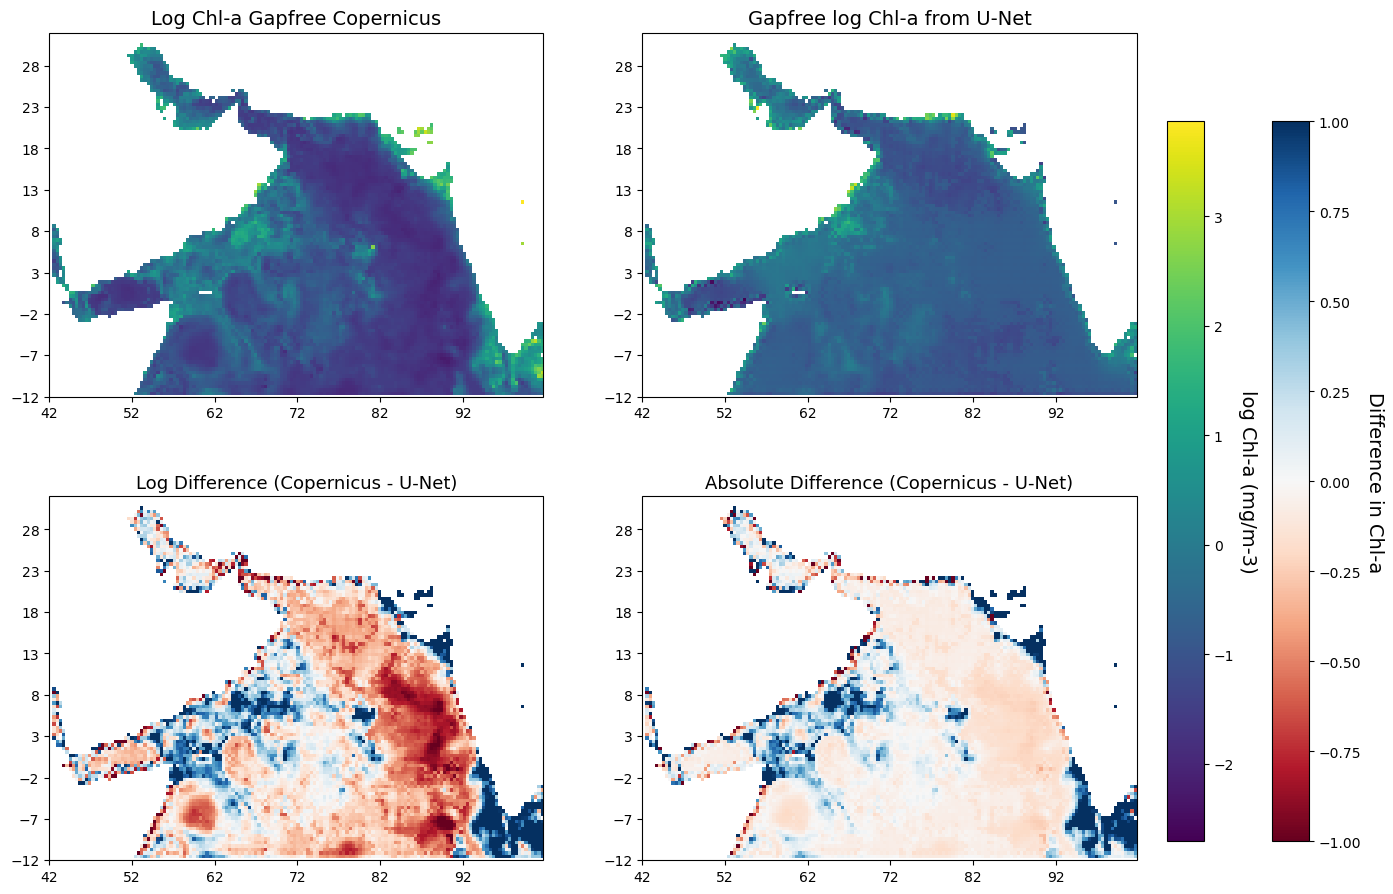

In [13]:
def plot_prediction_gapfill(zarr_stdized, model, date_to_predict):
    target_date = pd.to_datetime(date_to_predict)
    fake_cloud_date = target_date + pd.Timedelta(days=10)
    zarr_date = zarr_stdized.sel(time=target_date)
    
    try:
        fake_cloud_flag = zarr_stdized['CHL_cmes-cloud'].sel(time=fake_cloud_date).values
    except KeyError:
        fake_cloud_flag = zarr_date['CHL_cmes-cloud'].values 
    fake_cloud_flag = np.where(np.isnan(fake_cloud_flag), 0.0, fake_cloud_flag)
    
    raw_true_chl = zarr_date['CHL_cmes-gapfree'].values
    with np.errstate(divide='ignore', invalid='ignore'):
        log_true_chl = np.log(raw_true_chl)
    
    true_chl_std = (log_true_chl - y_mean) / y_std
    true_chl_std = np.where(np.isnan(true_chl_std), 0.0, true_chl_std)
    true_chl_std = np.where(np.isinf(true_chl_std), 0.0, true_chl_std)
    masked_chl = np.where(fake_cloud_flag == 1, 0.0, true_chl_std)
    
    day_of_year = target_date.dayofyear
    sin_grid = np.full(raw_true_chl.shape, np.sin(2 * np.pi * day_of_year / 365), dtype=np.float32)
    cos_grid = np.full(raw_true_chl.shape, np.cos(2 * np.pi * day_of_year / 365), dtype=np.float32)

    x_slice = []
    for var in X_vars:
        if var == 'masked_CHL': x_slice.append(masked_chl)
        elif var == 'fake_cloud_flag': x_slice.append(fake_cloud_flag)
        elif var == 'sin_time': x_slice.append(sin_grid)
        elif var == 'cos_time': x_slice.append(cos_grid)
        else:
            raw_val = np.where(np.isnan(zarr_date[var].values), 0.0, zarr_date[var].values)
            final_val = (raw_val - feature_stats[var][0]) / feature_stats[var][1] if var in feature_stats else raw_val
            x_slice.append(final_val)
            
    X = np.stack(x_slice, axis=-1).astype(np.float32)
    
    predicted_CHL_std = model.predict(X[np.newaxis, ...], verbose=0)[0, :, :, 0]
    predicted_CHL = (predicted_CHL_std * y_std) + y_mean
    
    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(zarr_date['CHL_cmes-gapfree'].values)
        
    predicted_CHL = np.where(np.isnan(true_CHL), np.nan, predicted_CHL)
    
    log_diff = true_CHL - predicted_CHL
    diff = np.exp(true_CHL) - np.exp(predicted_CHL)

    vmax, vmin = np.nanmax((true_CHL, predicted_CHL)), np.nanmin((true_CHL, predicted_CHL))
    extent = [42, 101.75, -11.75, 32]

    # Plotting
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    im0 = axes[0, 0].imshow(true_CHL, vmin=vmin, vmax=vmax, extent=extent, origin='upper', transform=ccrs.PlateCarree())
    axes[0, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 0].set_title('Log Chl-a Gapfree Copernicus', size=14)

    im1 = axes[0, 1].imshow(predicted_CHL, extent=extent, origin='upper', transform=ccrs.PlateCarree())
    axes[0, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[0, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[0, 1].set_title('Gapfree log Chl-a from U-Net', size=14)

    im2 = axes[1, 0].imshow(log_diff, vmin=-1, vmax=1, extent=extent, origin='upper', transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu)
    axes[1, 0].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 0].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 0].set_title('Log Difference (Copernicus - U-Net)', size=13)

    im3 = axes[1, 1].imshow(diff, vmin=-1, vmax=1, extent=extent, origin='upper', transform=ccrs.PlateCarree(), cmap=plt.cm.RdBu)
    axes[1, 1].set_xticks(np.arange(42, 102, 10), crs=ccrs.PlateCarree())
    axes[1, 1].set_yticks(np.arange(-12, 32, 5), crs=ccrs.PlateCarree())
    axes[1, 1].set_title('Absolute Difference (Copernicus - U-Net)', size=13)

    fig.subplots_adjust(right=0.85)
    cbar1 = fig.colorbar(im0, cax=fig.add_axes([0.87, 0.14, 0.025, 0.72]))
    cbar1.ax.set_ylabel('log Chl-a (mg/m-3)', rotation=270, size=14, labelpad=16)
    cbar2 = fig.colorbar(im2, cax=fig.add_axes([0.94, 0.14, 0.025, 0.72]))
    cbar2.ax.set_ylabel('Difference in Chl-a', rotation=270, size=14, labelpad=16)
    
    plt.subplots_adjust(top=0.96)
    plt.show()

# Run Gapfill Comparison
plot_prediction_gapfill(ds_cropped, model, '2020-09-08')

2026-06-30 04:12:31.409494: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=2} for conv %cudnn-conv-bias-activation.36 = (f32[8,64,104,152]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,6,104,152]{3,2,1,0} %bitcast.688, f32[64,6,3,3]{3,2,1,0} %bitcast.695, f32[64]{0} %bitcast.697), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="U-net_1/conv2d_1/convolution" source_file="/srv/conda/envs/notebook/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2026-06-30 04:12:31.447226: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potential

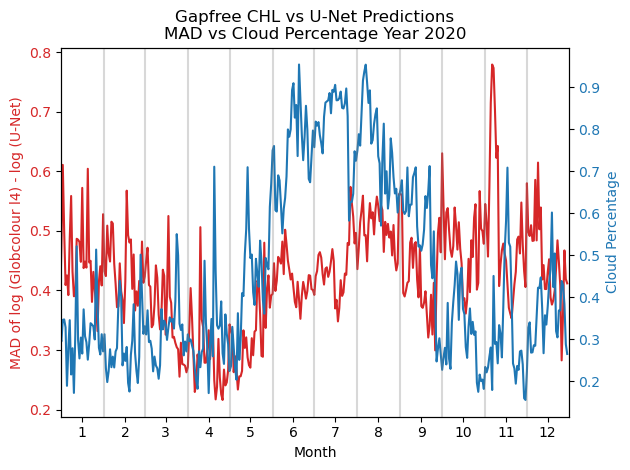

In [14]:
def get_cloud_perc(zarr_stdized, year):
    zarr_time_range = zarr_stdized.sel(time=str(year))
    if 'CHL_cmes-land' in zarr_stdized:
        non_land_cnt = np.sum(zarr_stdized['CHL_cmes-land'].values == 0)
    else:
        non_land_cnt = np.sum(~np.isnan(zarr_time_range['CHL_cmes-gapfree'].values[0]))
        
    clouds = zarr_time_range['CHL_cmes-cloud'].values
    cloud_perc = np.sum(clouds == 1, axis=(1, 2)) / non_land_cnt
    return cloud_perc

def yearly_MAD_vs_cloud(zarr_stdized, model, year):
    zarr_year = zarr_stdized.sel(time=str(year))
    
    # 1. Vectorized Feature Engineering
    real_clouds = zarr_year['CHL_cmes-cloud'].values
    fake_cloud_flag = np.roll(real_clouds, shift=-10, axis=0) 
    fake_cloud_flag = np.where(np.isnan(fake_cloud_flag), 0.0, fake_cloud_flag)
    
    raw_true_chl = zarr_year['CHL_cmes-gapfree'].values
    with np.errstate(divide='ignore', invalid='ignore'):
        log_true_chl = np.log(raw_true_chl)
        
    true_chl_std = (log_true_chl - y_mean) / y_std
    true_chl_std = np.where(np.isnan(true_chl_std), 0.0, true_chl_std)
    true_chl_std = np.where(np.isinf(true_chl_std), 0.0, true_chl_std)
    
    masked_chl = np.where(fake_cloud_flag == 1, 0.0, true_chl_std)
    
    doy = zarr_year['time'].dt.dayofyear.values[:, np.newaxis, np.newaxis]
    sin_grid = np.broadcast_to(np.sin(2 * np.pi * doy / 365), raw_true_chl.shape).astype(np.float32)
    cos_grid = np.broadcast_to(np.cos(2 * np.pi * doy / 365), raw_true_chl.shape).astype(np.float32)

    x_slice = []
    for var in X_vars:
        if var == 'masked_CHL': x_slice.append(masked_chl)
        elif var == 'fake_cloud_flag': x_slice.append(fake_cloud_flag)
        elif var == 'sin_time': x_slice.append(sin_grid)
        elif var == 'cos_time': x_slice.append(cos_grid)
        else:
            raw_val = np.where(np.isnan(zarr_year[var].values), 0.0, zarr_year[var].values)
            final_val = (raw_val - feature_stats[var][0]) / feature_stats[var][1] if var in feature_stats else raw_val
            x_slice.append(final_val)
            
    X = np.stack(x_slice, axis=-1).astype(np.float32)
    
    # 2. Predict & Evaluate
    predicted_CHL_std = model.predict(X, batch_size=8, verbose=0)[:, :, :, 0]
    predicted_CHL = (predicted_CHL_std * y_std) + y_mean
    
    with np.errstate(divide='ignore', invalid='ignore'):
        true_CHL = np.log(zarr_year['CHL_cmes-gapfree'].values)
        flag = zarr_year['CHL_cmes-level3'].values
        
    predicted_CHL = np.where(~np.isnan(flag), np.nan, predicted_CHL)
    
    mae = [mtg.compute_mae(true, pred) for true, pred in zip(true_CHL, predicted_CHL)]
    cloud_perc = get_cloud_perc(zarr_stdized, year)

    # 3. Plotting
    fig, ax1 = plt.subplots()
    ax1.set_xlabel('Month')
    ax1.set_ylabel('MAD of log (Globcolour l4) - log (U-Net)', color='tab:red')
    ax1.plot(mae, color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()  
    ax2.set_ylabel('Cloud Percentage', color='tab:blue')  
    ax2.plot(cloud_perc, color='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    tick_pos, tick_label, total_day = [], [], 1
    tick_pos.append(total_day + 15)
    tick_label.append('1')
    
    for month in range(1, 12):
        total_day += calendar.monthrange(year, month)[1]
        plt.axvline(total_day, color='grey', alpha=0.3)
        tick_pos.append(total_day + 15)
        tick_label.append(str(month+1))
        
    plt.title(f'Gapfree CHL vs U-Net Predictions\nMAD vs Cloud Percentage Year {year}')
    plt.xlim(1, len(mae))
    plt.xticks(tick_pos, tick_label)

    fig.tight_layout() 
    plt.show()

# Run Annual Evaluation
yearly_MAD_vs_cloud(ds_cropped, model, 2020)